# 02 - Preprocessing Generale

Questo notebook centralizza la preparazione dei dati per i successivi esperimenti.
La logica di creazione delle trasformazioni e dei Dataloader è stata fattorizzata all'interno del modulo `src.dataset` per garantire la massima pulizia del codice e risolvere problemi legati al multiprocessing su Windows.

In [1]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

import torch
import matplotlib.pyplot as plt
import numpy as np
from src.dataset import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device selezionato: {device}")

Device selezionato: cuda


## 1. Caricamento Dati

Utilizziamo la funzione `get_dataloaders` del nostro package per istanziare i loader con le trasformazioni di default (risoluzione 64x64, RandomCrop per train, CenterCrop per test).

In [2]:
if __name__ == '__main__':
    train_loader, val_loader, test_loader = get_dataloaders(
        data_dir="../_data", 
        batch_size=128, 
        num_workers=8, 
        device=device
    )
    
    print(f"Batch per epoca (train): {len(train_loader)}")
    print(f"Batch per epoca (test): {len(test_loader)}")

Batch per epoca (train): 167
Batch per epoca (test): 99


## 2. Sanity Check (Verifica Visiva)

Estraiamo un singolo batch dal DataLoader di training per assicurarci che le dimensioni siano corrette e visualizziamo un paio di immagini.

Shape del batch di immagini: torch.Size([128, 3, 64, 64])
Shape del batch di etichette: torch.Size([128])


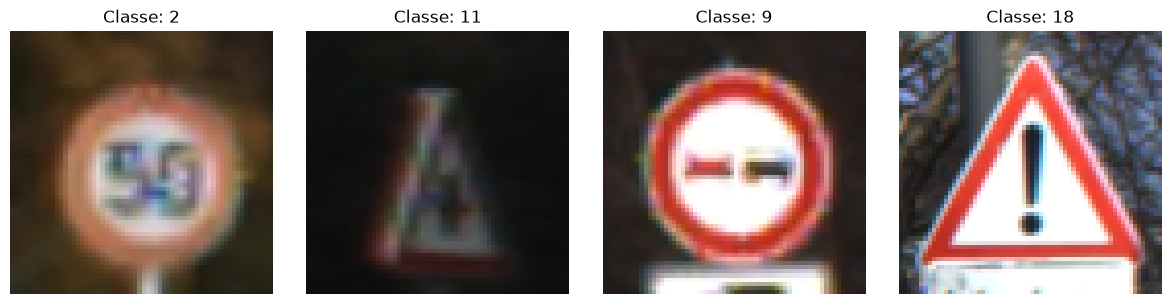

In [3]:
if __name__ == '__main__':
    images, labels = next(iter(train_loader))
    print(f"Shape del batch di immagini: {images.shape}")
    print(f"Shape del batch di etichette: {labels.shape}")
    
    # Visualizzazione delle prime 4 immagini
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for i in range(4):
        # Denormalizzazione per visualizzazione corretta
        img = images[i].numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Classe: {labels[i].item()}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()